## Лабораторная работа: Гамма-распределение
### Цель работы:
1. Сгенерировать выборку случайных чисел, распределённых по закону гамма-распределения.
2. Рассчитать теоретические и выборочные числовые характеристики.
3. Построить графики теоретической и эмпирической функций распределения, а также гистограмму и теоретическую плотность.
4. Оценить меру расхождения между теорией и выборкой.

Для начала определим необходимые импорты

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gamma

### Гамма-распределение
Гамма-распределение – это непрерывное распределение с плотностью:
$$
f(x) = \frac{x^{k-1} e^{-x/\theta}}{\theta^k \Gamma(k)}, \quad x > 0
$$
где:
- $k > 0$ – параметр формы (shape)
- $\theta > 0$ – параметр масштаба (scale)
- $\Gamma(k)$ – гамма-функция

В работе приняты параметры:
$$
k = 2.0, \quad \theta = 3.0
$$

In [40]:
shape = 2.0   # k
scale = 3.0   # θ

n = 200

np.random.seed(21)
sample = gamma.rvs(a=shape, scale=scale, size=n)

### Теоретические числовые характеристики
Для гамма-распределения математическое ожидание вычисляется по формуле:
$$
M[X] = k \cdot \theta
$$
Подстановка значений даёт $M[X] = 2 \cdot 3 = 6$.

Дисперсия вычисляется по формуле:
$$
D[X] = k \cdot \theta^2
$$
Подстановка значений даёт $D[X] = 2 \cdot 3^2 = 18$.

In [41]:
theor_mean = shape * scale
theor_var = shape * (scale ** 2)

print(f"Теоретическое мат.ожидание: {theor_mean:.4f}")
print(f"Теоретическая дисперсия: {theor_var:.4f}")

Теоретическое мат.ожидание: 6.0000
Теоретическая дисперсия: 18.0000


### Выборочные числовые характеристики
Пусть выборка $x_1, x_2, \dots, x_n$ имеет объём $n = 200$.

Выборочное среднее – оценка теоретического математического ожидания:
$$
\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i
$$
Выборочная дисперсия (несмещённая) – оценка теоретической дисперсии:
$$
s^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2
$$
Размах выборки – разность между максимальным и минимальным значениями.

Выборочная медиана – центральный элемент упорядоченного ряда.


In [58]:
sample_mean = np.mean(sample)
sample_var = np.var(sample, ddof=1)
sample_range = np.max(sample) - np.min(sample)
sample_median = np.median(sample)

print(f"Выборочное среднее: {sample_mean:.4f}")
print(f"Выборочная дисперсия (несмещенная): {sample_var:.4f}")
print(f"Размах выборки: {sample_range:.4f}")
print(f"Выборочная медиана: {sample_median:.4f}")

Выборочное среднее: 5.9938
Выборочная дисперсия (несмещенная): 19.8480
Размах выборки: 24.8710
Выборочная медиана: 4.7555


### Функции распределения и мера их расхождения
Теоретическая функция распределения:
$$
F(x) = \int_0^x \frac{t^{k-1} e^{-t/\theta}}{\theta^k \Gamma(k)} dt
$$
Выборочная функция распределения определяется как доля элементов выборки, не превосходящих заданное значение $x$.

Мера расхождения вычисляется как максимальное абсолютное отклонение между эмпирической и теоретической функциями:
$$
D_n = \max_x \left| \hat{F}_n(x) - F(x) \right|
$$
Чем меньше $D_n$, тем лучше выборка соответствует теории.

In [43]:
x_sorted = np.sort(sample)
theoretical_function = gamma.cdf(x_sorted, a=shape, scale=scale)
empirical_function = np.arange(1, n + 1) / n

measure_of_discrepancy = np.max(np.abs(empirical_function - theoretical_function))
print(f"Мера расхождения: {measure_of_discrepancy:.6f}")

Мера расхождения: 0.038013


Теперь строим график

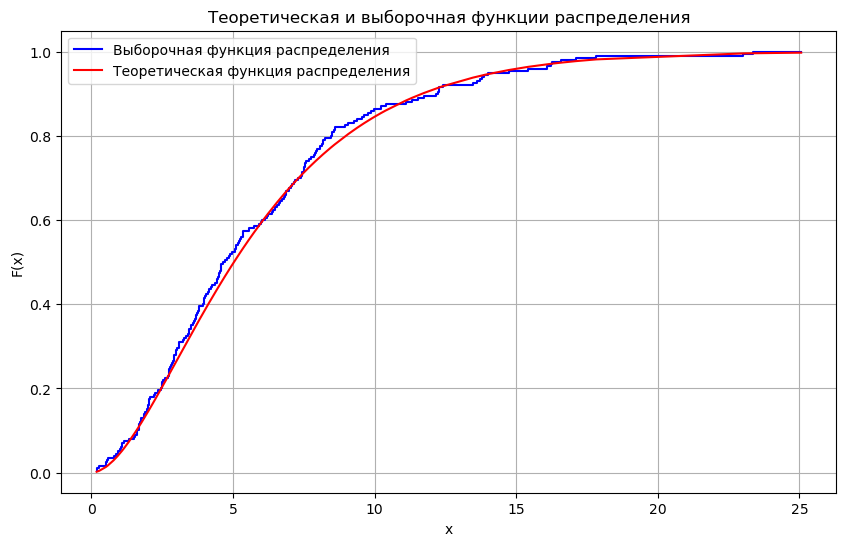

In [44]:
plt.figure(figsize=(10, 6))
plt.step(x_sorted, empirical_function, color='blue', label='Выборочная функция распределения')
plt.plot(x_sorted, theoretical_function, color='red', label='Теоретическая функция распределения')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Теоретическая и выборочная функции распределения')
plt.legend()
plt.grid(True)
plt.show()

### Гистограмма и теоретическая плотность

Гистограмма строится путём разбиения диапазона выборки на $m$ интервалов равной ширины. Для каждого интервала определяется частота – количество элементов выборки, попавших в него.

Теоретическая плотность гамма-распределения вычисляется в центре каждого интервала $c_j = \frac{b_j + b_{j+1}}{2}$ по формуле:
$$
f(c_j) = \frac{c_j^{k-1} e^{-c_j/\theta}}{\theta^k \Gamma(k)}
$$
Для сравнения гистограммы с теоретической плотностью гистограмма приводится к плотности: высота столбца $j$ равна частоте, делённой на объём выборки и на ширину интервала. Это позволяет сопоставить её с теоретической кривой.

Максимум разности вычисляется как максимальное абсолютное отклонение между приведённой к плотности гистограммой и теоретической плотностью:
$$
\Delta = \max_j \left| \frac{\nu_j}{n \cdot h} - f(c_j) \right|
$$
где $\nu_j$ – частота в интервале $j$, $h$ – ширина интервала, $n$ - объем выборки.

Эта величина показывает, насколько сильно гистограмма отклоняется от теоретического распределения.

Для начала вычислим нашу гистограмму и теоретическую и эмпирическую плотность распределения, а также максимальную разницу между ними

In [55]:
m = 15
counts, bin_edges = np.histogram(sample, bins=m)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

empirical_density = counts / (n * bin_width)
theoretical_density = gamma.pdf(bin_centers, a=shape, scale=scale)

max_density_diff = np.max(np.abs(empirical_density - theoretical_density))
print(f"Максимум разности плотностей: {max_density_diff:.6f}")

Максимум разности плотностей: 0.021084


Теперь построим таблицу сравнения

In [56]:
table = pd.DataFrame({
    'Интервал': [f"[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})" for i in range(m)],
    'Центр интервала': bin_centers,
    'Частота': counts,
    'Выборочная плотность': empirical_density,
    'Теоретическая плотность': theoretical_density
})
print("Таблица частот и плотностей:")
print(table.to_string(justify='center'))

Таблица частот и плотностей:
        Интервал      Центр интервала  Частота  Выборочная плотность  Теоретическая плотность
0     [0.189, 1.847)      1.017865       25           0.075389               0.080556        
1     [1.847, 3.505)      2.675931       42           0.126654               0.121857        
2     [3.505, 5.163)      4.333997       40           0.120622               0.113563        
3     [5.163, 6.821)      5.992063       23           0.069358               0.090343        
4     [6.821, 8.479)      7.650129       29           0.087451               0.066368        
5    [8.479, 10.137)      9.308195       13           0.039202               0.046465        
6   [10.137, 11.795)     10.966261        6           0.018093               0.031498        
7   [11.795, 13.453)     12.624327        5           0.015078               0.020864        
8   [13.453, 15.111)     14.282393        7           0.021109               0.013582        
9   [15.111, 16.769)     15.940

Теперь строим график

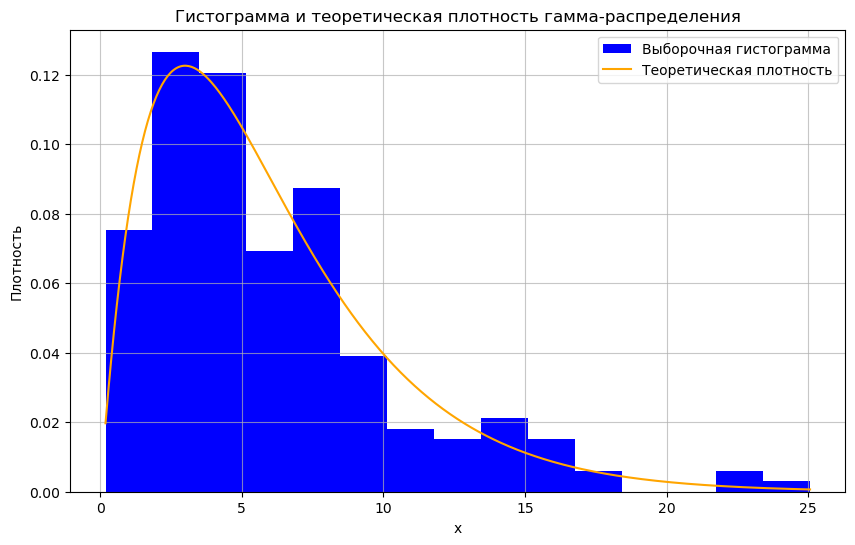

In [59]:
plt.figure(figsize=(10, 6))
plt.hist(sample, bins=m, density=True, color='blue', label='Выборочная гистограмма')

x_grid = np.linspace(min(sample), max(sample), 500)
plt.plot(x_grid, gamma.pdf(x_grid, a=shape, scale=scale), color='orange', label='Теоретическая плотность')

plt.xlabel('x')
plt.ylabel('Плотность')
plt.title('Гистограмма и теоретическая плотность гамма-распределения')
plt.legend()
plt.grid(True, alpha=0.7)
plt.show()

## Выводы
В ходе работы была сгенерирована выборка объёмом $n = 200$ из гамма-распределения с параметрами $k = 2.0$, $\theta = 3.0$.

**Числовые характеристики**  
Теоретическое среднее ($6.000$) и выборочное среднее ($5.9938$) близки.  
Теоретическая дисперсия ($18.000$) и выборочная дисперсия ($19.848$) близки.

**Функции распределения**  
Мера расхождения теоретической и выборочной функций распределения ($D_n = 0.038013$) мала, их графики визуально совпадают, но, что и понятно, график выборочной функции распределения менее гладкий, чем теоретической.

**Плотность**  
Гистограмма повторяет форму теоретической плотности. Максимальное отклонение плотностей ($\Delta = 0.021084$) невелико.